In [2]:
import sys, pdb, string,os
homedir = os.environ["HOME"]
olddir = homedir+'/Dropbox/other_repositories/rpc_hydro/pysrc/'
sys.path.append(olddir)
import Cloudy
import numpy as np
from numpy import log10 as log
import pylab as pl
from astropy import units as un, constants as cons
#import my_utils as u


In [3]:
reload(Cloudy)
Cloudy.Model.basedir = homedir+'/Dropbox/github_repositories/gizmo_analysis/ipynb/Halpha_emission/CloudyOutput/'
Cloudy.Model.cloudyexe = homedir+'/programs/Cloudy/c17.03/source/cloudy.exe'

In [4]:
emissionlines = [el for el in Cloudy.emissionLines if el.cloudyName in  ('H  1 6562.81',)]

In [5]:
singleTemperatureGrids = Cloudy.Grid('constant_temperature', luminosities=[38],
                                   electronTemps=np.arange(3.,7,0.1),
                           emissionLines=emissionlines,savelevel=1,useIR=False,
                           ps=[False],radii=[21.5], hasdust=False,aEUVs=[-1.6],Zs=[1.],
                                  ns=[-3],colDenss=[15.])


In [107]:
singleTemperatureGrids.writeinputfiles()

In [108]:
singleTemperatureGrids.run()

Grid.run()
module name: my_utils
parent process: 8759
process id: 51301
# of models to run: 40
running (15:46:51): constant_temperature_t3.0 process id: 52422
running (15:46:51): constant_temperature_t3.1 process id: 52423
running (15:46:51): constant_temperature_t3.2 process id: 52424
running (15:46:51): constant_temperature_t3.3 process id: 52425


running (15:46:51): constant_temperature_t3.4 process id: 52426
running (15:46:51): constant_temperature_t3.5 process id: 52427
running (15:46:51): constant_temperature_t3.6 process id: 52428
ending (15:46:58): constant_temperature_t3.6 process id: 52428
ending (15:46:58): constant_temperature_t3.1 process id: 52423
ending (15:46:58): constant_temperature_t3.3 process id: 52425
ending (15:46:58): constant_temperature_t3.4 process id: 52426
ending (15:46:58): constant_temperature_t3.2 process id: 52424
ending (15:46:58): constant_temperature_t3.5 process id: 52427
ending (15:46:58): constant_temperature_t3.0 process id: 52422


In [6]:
singleTemperatureGrids.loadAll()

progress:  100% 14 seconds passed


In [7]:
coeff = cons.h*3e18/6562.81*un.s**-1 * (10.**-3*un.cm**-3)**2 
res = np.array([(10.**k,
                singleTemperatureGrids[k].linesdicF[6562.81].mean()*(un.erg/un.s/un.cm**3. / coeff).to('cm**3*s**-1').value)
 for k in singleTemperatureGrids.keys()]).T

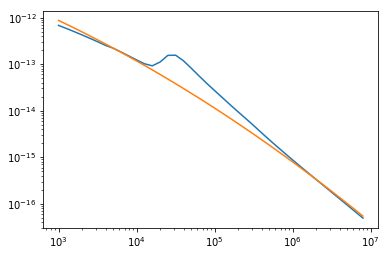

In [15]:
pl.loglog(res[0],res[1])
pl.plot(res[0], 1.17e-13 * (res[0]/1e4)**(-0.942-0.031*np.log(res[0]/1e4)))

In [10]:
np.savez('/Users/jonathanstern/Dropbox/github_repositories/gizmo_analysis/pyobjs/Ha_recombination_coefficient',
        Ts=res[0],alphas=res[1])